## GWAS annotation

In [1]:
!wget https://storage.googleapis.com/adult-gtex/bulk-qtl/v10/single-tissue-cis-qtl/GTEx_Analysis_v10_eQTL.tar

--2026-02-12 15:18:21--  https://storage.googleapis.com/adult-gtex/bulk-qtl/v10/single-tissue-cis-qtl/GTEx_Analysis_v10_eQTL.tar
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.69.187, 142.250.73.155, 142.250.73.91, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.69.187|:443... failed: Connection timed out.
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.73.155|:443... failed: Connection refused.
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.73.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2561047718 (2.4G) [application/x-tar]
Saving to: ‘GTEx_Analysis_v10_eQTL.tar.1’

GTEx_Analysis_v10_e 100%[===================>]   2.38G  15.5MB/s    in 2m 40s  

2026-02-12 15:23:12 (15.3 MB/s) - ‘GTEx_Analysis_v10_eQTL.tar.1’ saved [2561047718/2561047718]



In [2]:
!tar -zxvf GTEx_Analysis_v10_eQTL.tar

GTEx_Analysis_v10_eQTL_updated/
GTEx_Analysis_v10_eQTL_updated/Prostate.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Stomach.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Skin_Not_Sun_Exposed_Suprapubic.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Spleen.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Minor_Salivary_Gland.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Heart_Left_Ventricle.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Pituitary.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Minor_Salivary_Gland.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Esophagus_Mucosa.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Brain_Cerebellar_Hemisphere.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Adipose_Subcutaneous.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Adrenal_Gland.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Nerve_Tibial.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Uterus.v10.eG

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load GWAS variant data
df_gwas = pd.read_csv("../../results/reproducibility/gwas_resources/match_GWAS.csv")

# Mapping between cell lines and GTEx tissues
cell_to_gtex = {
    'HepG2': 'Liver',
    'K562': 'Whole_Blood',
    'HEK293': 'Kidney_Cortex',
    'HEK293T': 'Kidney_Cortex',
}

# Function to load GTEx eQTL summary data
def load_eqtl_data(gtex_file):
    """
    Load GTEx eQTL data from a gzip-compressed tab-delimited file.
    """
    return pd.read_csv(gtex_file, sep="\t", compression="gzip")

# List to store processed results from all cell lines
eqtl_dfs = []

# Iterate through each cell line and its corresponding GTEx tissue
for cell_line, gtex_organ in cell_to_gtex.items():
    # Load the corresponding GTEx eQTL file
    gtex_file = f"GTEx_Analysis_v10_eQTL_updated/{gtex_organ}.v10.eGenes.txt.gz"
    eqtl_data = load_eqtl_data(gtex_file)

    # Rename rsID column for consistency with GWAS data
    eqtl_data.rename(columns={'rs_id_dbSNP155_GRCh38p13': 'rsid'}, inplace=True)

    # Filter GWAS variants for the current cell line
    df_cell = df_gwas[df_gwas['cell'] == cell_line]

    # Merge GWAS data with eQTL data by rsID
    df_merge = df_cell.merge(eqtl_data[['rsid', 'pval_nominal']], on='rsid', how='left')

    # Compute -log10(p) for eQTL p-values (missing values are set to 1 → log10(1) = 0)
    df_merge['log10_p'] = -np.log10(df_merge['pval_nominal'].fillna(1.0))

    # Mark significant eQTLs (p-value < 1e-5)
    threshold = 1e-5
    df_merge['is_significant_eqtl'] = df_merge['pval_nominal'] < threshold

    # Add cell line label
    df_merge['cell_line'] = cell_line

    # Append processed data to the list
    eqtl_dfs.append(df_merge)

# Combine all processed data into one DataFrame
all_data = pd.concat(eqtl_dfs, ignore_index=True)
output_eqtl_gwas = "../../results/reproducibility/gwas_resources/all_eqtl_gwas_data.csv"
# Save the merged dataset to a CSV file
all_data.to_csv(output_eqtl_gwas, index=False)


In [4]:
import pandas as pd

# 1. Load the full dataset
df = pd.read_csv('../../results/reproducibility/gwas_resources/all_eqtl_gwas_data.csv')

# 2. Keep significant eQTLs only and extract the required columns
sig_df = (
    df[df['is_significant_eqtl']]
    .loc[:, ['cell_line', 'log10_p']]
    .reset_index(drop=True)
)

# 3. Save as a new CSV
out_path = '../../results/reproducibility/gwas_resources/sig_eqtl_cell_log10p.csv'
sig_df.to_csv(out_path, index=False)

sig_df.head(10)

,cell_line,log10_p
0,HepG2,5.729426
1,HepG2,6.495945
2,HepG2,6.495945
3,HepG2,5.704411
4,HepG2,5.090064
5,HepG2,80.304271
6,HepG2,8.054709
7,HepG2,5.447022
8,HepG2,6.947668
9,HepG2,6.947668


```{important}
**How to use R code in this notebook?**

We have developed several R scripts to perform downstream analyses, and the essential code for key analyses is provided below. To interactively execute the analysis within this notebook, we utilize the `rpy2` package, which allows running R code directly. Thus, please ensure that `rpy2` is installed (`conda install conda-forge::rpy2`). Alternatively, you may extract these R scripts and execute them externally as standalone R scripts.

The code below initializes `rpy2`. After this setup, you can write and execute R code directly within notebook cells by starting with `%%R`.
```

In [5]:
import logging
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import pandas2ri
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
pandas2ri.activate()
%load_ext rpy2.ipython

In [ ]:
%%R
library(ggplot2)
library(dplyr)
library(readr)
library(ggsignif)
library(showtext)     # Embed TrueType fonts
library(grid)         # gpar()

       comparison      p_value label
1   HepG2 vs K562 1.467423e-47   ***
2 K562 vs HEK293T 3.466562e-02     *
3  K562 vs HEK293 1.333591e-11   ***


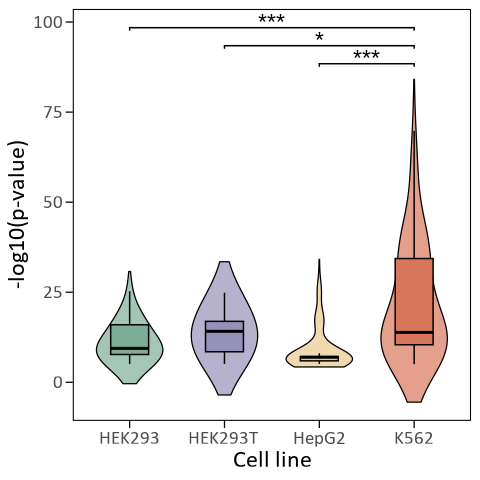

In [7]:
%%R
# ------------ 1. Register & activate Calibri ---------------------------------------
# Windows ships with Calibri; on Mac/Linux, replace with a local TTF path
font_add(
  family = "Calibri",
  regular     = "C:/Windows/Fonts/calibri.ttf",
)
showtext_auto()                 # Render subsequent plots with showtext
font_calibri <- gpar(fontfamily = "Calibri")   # Reusable gpar object
# ==============================================================
# 1. Data
# ==============================================================
sig_data <- read_csv(
  '../../results/reproducibility/gwas_resources/sig_eqtl_cell_log10p.csv',
  show_col_types = FALSE
)

# Remove outliers (1.5×IQR)
sig_data <- sig_data %>% 
  group_by(cell_line) %>% 
  filter(
    between(
      log10_p,
      quantile(log10_p, 0.25) - 1.5 * IQR(log10_p),
      quantile(log10_p, 0.75) + 1.5 * IQR(log10_p)
    )
  ) %>% 
  ungroup()

# Split data frames by group
hepG2_df   <- filter(sig_data,  cell_line == "HepG2")
others_df  <- filter(sig_data,  cell_line != "HepG2")

# ==============================================================
# 2. Colors & significance
# ==============================================================
cell_cols <- c(
  "HepG2"   = "#ebc88d",
  "K562"    = "#d8765c",
  "HEK293"  = "#7cad96",
  "HEK293T" = "#9691b8"
)

comparisons <- list(
  c("HepG2",  "K562"),
  c("K562",   "HEK293T"),
  c("K562",   "HEK293")
)
y_positions <- c(85, 90, 95)

# Compute p-values for each comparison (Wilcoxon rank-sum test)
get_p <- function(g1, g2, data) {
  d <- data %>% filter(cell_line %in% c(g1, g2))
  wilcox.test(log10_p ~ cell_line, data = d)$p.value
}
p_values <- vapply(comparisons, function(x) get_p(x[1], x[2], sig_data), numeric(1))

# Map p-values to significance labels (stars)
p_to_label <- function(p) {
  if (is.na(p)) return("NA")
  if (p < 0.001) return("***")
  if (p < 0.01)  return("**")
  if (p < 0.05)  return("*")
  return("ns")
}
labels <- vapply(p_values, p_to_label, character(1))

# Show computed p-values in the output (for transparency)
print(data.frame(
  comparison = vapply(comparisons, function(x) paste(x[1], "vs", x[2]), character(1)),
  p_value    = p_values,
  label      = labels
))

# ==============================================================
# 3. Plot
# ==============================================================
# 3. Plot ---- Only change: pass sig_data into ggplot() and set global aesthetics
p <- ggplot(sig_data, aes(x = cell_line, y = log10_p, fill = cell_line)) +

  # HepG2 violin (adjust = 10)
  geom_violin(data = hepG2_df,
              width = 0.7, scale = "width", adjust = 10,
              colour = "black", size = 0.6, alpha = 0.7,
              trim = FALSE) +

  # Other cell lines violin (adjust = 2.5)
  geom_violin(data = others_df,
              width = 0.7, scale = "width", adjust = 2.5,
              colour = "black", size = 0.6, alpha = 0.7,
              trim = FALSE) +

  # Shared boxplot
  geom_boxplot(width = 0.4, outlier.shape = NA,
               colour = "black", size = 0.7, alpha = 1) +

  # Significance brackets — x mapping is now defined, so it renders correctly
  geom_signif(
    comparisons = comparisons,
    annotations = labels,
    y_position  = y_positions,
    vjust       = 0.4,
    tip_length  = 0.01,
    textsize    = 6,
    size        = 0.7
  ) +

  scale_fill_manual(values = cell_cols) +
  labs(x = "Cell line", y = "-log10(p-value)") +
  theme_minimal(base_family = "Calibri", base_size = 18) +
  theme(
    legend.position    = "none",
    panel.border       = element_rect(colour = "black", fill = NA, size = 1),
    panel.grid         = element_blank(),
    axis.ticks         = element_line(size = 0.6),
    axis.ticks.length  = unit(0.25, "cm")
  )

# ==============================================================
# 5. Display
# ==============================================================
print(p)